

Сравниваются:
- Base DQN;
- DQN + Prioritized Replay;
- Dueling DQN;
- Noisy DQN.

## 1. Установка зависимостей

In [1]:
!pip -q install swig
!pip -q install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.0 MB/s eta 0:00:00


## 2. Код реализации

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Noisy Networks Layer
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))

    def _scale_noise(self, size):
        x = torch.randn(size, device=device)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(x, weight, bias)

# Модульная Нейросеть (DQN / Dueling / Noisy)

class ConfigurableDQN(nn.Module):
    def __init__(self, input_dim, output_dim, use_dueling=False, use_noisy=False):
        super(ConfigurableDQN, self).__init__()
        self.use_dueling = use_dueling
        self.use_noisy = use_noisy

        # Функция для создания слоев (обычных или Noisy)
        def linear_layer(in_dim, out_dim):
            return NoisyLinear(in_dim, out_dim) if use_noisy else nn.Linear(in_dim, out_dim)

        self.feature = nn.Sequential(
            linear_layer(input_dim, 128),
            nn.ReLU()
        )

        if self.use_dueling:
            self.value_stream = nn.Sequential(
                linear_layer(128, 128),
                nn.ReLU(),
                linear_layer(128, 1)
            )
            self.advantage_stream = nn.Sequential(
                linear_layer(128, 128),
                nn.ReLU(),
                linear_layer(128, output_dim)
            )
        else:
            self.q_stream = nn.Sequential(
                linear_layer(128, 128),
                nn.ReLU(),
                linear_layer(128, output_dim)
            )

    def forward(self, state):
        features = self.feature(state)
        if self.use_dueling:
            values = self.value_stream(features)
            advantages = self.advantage_stream(features)
            qvals = values + (advantages - advantages.mean(dim=1, keepdim=True))
        else:
            qvals = self.q_stream(features)
        return qvals

    def reset_noise(self):
        if self.use_noisy:
            for module in self.modules():
                if isinstance(module, NoisyLinear):
                    module.reset_noise()

# Буферы памяти (Обычный и Prioritized)
class StandardBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=None):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*samples)
        # Возвращаем единичные веса для совместимости с PER
        weights = np.ones(batch_size, dtype=np.float32)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones), None, weights)

    def update_priorities(self, indices, priorities):
        pass # Для обычного буфера ничего не делаем

    def __len__(self):
        return len(self.buffer)

class PrioritizedBuffer(StandardBuffer):
    def __init__(self, capacity, prob_alpha=0.6):
        super().__init__(capacity)
        self.prob_alpha = prob_alpha
        self.priorities = np.zeros((capacity,), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        super().push(state, action, reward, next_state, done)
        # pos обновился в super().push, поэтому берем предыдущий индекс
        idx = (self.pos - 1) % self.capacity
        self.priorities[idx] = max_prio

    def sample(self, batch_size, beta=0.4):
        prios = self.priorities[:len(self.buffer)]
        probs = prios ** self.prob_alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = np.array(weights, dtype=np.float32)

        states, actions, rewards, next_states, dones = zip(*samples)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones), indices, weights)

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio

# Агент с поддержкой конфигураций
class ConfigurableAgent:
    def __init__(self, state_dim, action_dim, config):
        self.action_dim = action_dim
        self.config = config

        self.model = ConfigurableDQN(state_dim, action_dim, config['use_dueling'], config['use_noisy']).to(device)
        self.target_model = ConfigurableDQN(state_dim, action_dim, config['use_dueling'], config['use_noisy']).to(device)
        self.target_model.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-3)

        if config['use_per']:
            self.memory = PrioritizedBuffer(100000)
        else:
            self.memory = StandardBuffer(100000)

        self.batch_size = 64
        self.gamma = 0.99
        self.beta = 0.4
        self.beta_frames = 100000

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def get_action(self, state):
        # Epsilon-greedy для стандартных сетей
        if not self.config['use_noisy'] and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return q_values.argmax(1).item()

    def decay_epsilon(self):
        if not self.config['use_noisy']:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def compute_loss(self):
        if len(self.memory) < self.batch_size:
            return None

        state, action, reward, next_state, done, indices, weights = self.memory.sample(self.batch_size, self.beta)

        state = torch.FloatTensor(state).to(device)
        next_state = torch.FloatTensor(next_state).to(device)
        action = torch.LongTensor(action).to(device)
        reward = torch.FloatTensor(reward).to(device)
        done = torch.FloatTensor(done).to(device)
        weights = torch.FloatTensor(weights).to(device)

        q_values = self.model(state)
        q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # Standard Double DQN
            next_q_values = self.model(next_state)
            next_actions = next_q_values.argmax(1)
            next_q_target_values = self.target_model(next_state)
            next_q_value = next_q_target_values.gather(1, next_actions.unsqueeze(1)).squeeze(1)
            expected_q_value = reward + self.gamma * next_q_value * (1 - done)

        loss = (q_value - expected_q_value.detach()).pow(2) * weights
        prios = loss + 1e-5
        loss = loss.mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.model.reset_noise()
        self.target_model.reset_noise()

        if self.config['use_per']:
            self.memory.update_priorities(indices, prios.data.cpu().numpy())

        return loss.item()

# Цикл обучения и экспериментов
def train_agent(env_name, config, episodes=1000):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = ConfigurableAgent(state_dim, action_dim, config)
    rewards_history = []
    # Для построения честных графиков будем сохранять реальную награду среды отдельно
    real_rewards_history = []
    frame_idx = 0

    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        real_episode_reward = 0
        done = False

        while not done:
            frame_idx += 1
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            real_episode_reward += reward

            if env_name == "MountainCar-v0":
                position, velocity = next_state
                # Награда за высоту (чем дальше от центра ямы, тем лучше)
                custom_reward = reward + (abs(position + 0.5) * 10.0) + (abs(velocity) * 50.0)

                if position >= 0.5:
                    custom_reward += 1000.0
            else:
                custom_reward = reward

            agent.memory.push(state, action, custom_reward, next_state, done)
            state = next_state
            episode_reward += custom_reward

            agent.compute_loss()

            if config['use_per']:
                agent.beta = min(1.0, agent.beta + (1.0 - 0.4) / agent.beta_frames)

            if frame_idx % 1000 == 0:
                agent.update_target()

        agent.decay_epsilon()
        rewards_history.append(episode_reward)
        real_rewards_history.append(real_episode_reward)

        if (episode + 1) % 50 == 0:
            avg_real = np.mean(real_rewards_history[-50:])
            print(f"Окружение: {env_name} | Эпизод: {episode+1:3d} | Ср. реальная награда: {avg_real:.2f}")

    env.close()
    return real_rewards_history

def smooth_curve(rewards, window=20):
    """Сглаживание графика скользящим средним для наглядности"""
    smoothed = []
    for i in range(len(rewards)):
        start = max(0, i - window)
        smoothed.append(np.mean(rewards[start:i+1]))
    return smoothed

## 3. Запуск LunarLander-v3

=== Запуск эксперимента на LunarLander-v3 ===

Обучение модели: Base DQN
Окружение: LunarLander-v3 | Эпизод:  50 | Ср. реальная награда: -145.22
Окружение: LunarLander-v3 | Эпизод: 100 | Ср. реальная награда: -103.47
Окружение: LunarLander-v3 | Эпизод: 150 | Ср. реальная награда: -55.36
Окружение: LunarLander-v3 | Эпизод: 200 | Ср. реальная награда: -90.55
Окружение: LunarLander-v3 | Эпизод: 250 | Ср. реальная награда: -16.72
Окружение: LunarLander-v3 | Эпизод: 300 | Ср. реальная награда: 52.45
Окружение: LunarLander-v3 | Эпизод: 350 | Ср. реальная награда: 190.82
Окружение: LunarLander-v3 | Эпизод: 400 | Ср. реальная награда: 194.96
Окружение: LunarLander-v3 | Эпизод: 450 | Ср. реальная награда: 152.76
Окружение: LunarLander-v3 | Эпизод: 500 | Ср. реальная награда: 234.03
Окружение: LunarLander-v3 | Эпизод: 550 | Ср. реальная награда: 222.36
Окружение: LunarLander-v3 | Эпизод: 600 | Ср. реальная награда: 218.57
Окружение: LunarLander-v3 | Эпизод: 650 | Ср. реальная награда: 243.99
Окр

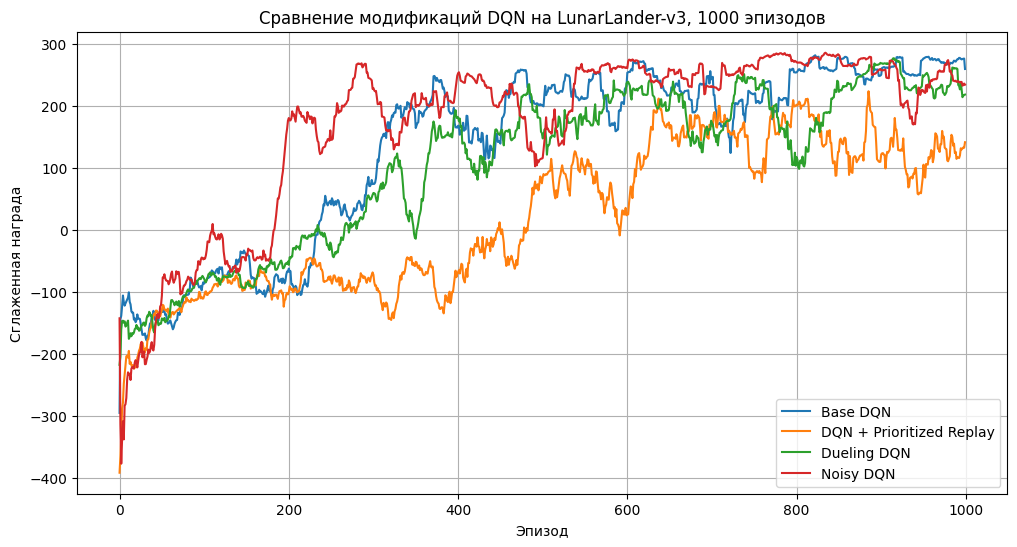

In [3]:
experiments = {
    "Base DQN": {"use_per": False, "use_dueling": False, "use_noisy": False},
    "DQN + Prioritized Replay": {"use_per": True, "use_dueling": False, "use_noisy": False},
    "Dueling DQN": {"use_per": False, "use_dueling": True, "use_noisy": False},
    "Noisy DQN": {"use_per": False, "use_dueling": False, "use_noisy": True},
}

episodes = 1000

env_name = "LunarLander-v3"

plt.figure(figsize=(12, 6))

print(f"=== Запуск эксперимента на {env_name} ===")
for name, config in experiments.items():
    print(f"\nОбучение модели: {name}")
    rewards = train_agent(env_name, config, episodes=episodes)
    smoothed_rewards = smooth_curve(rewards)
    plt.plot(smoothed_rewards, label=name)

plt.title(f"Сравнение модификаций DQN на {env_name}, {episodes} эпизодов")
plt.xlabel("Эпизод")
plt.ylabel("Сглаженная награда")
plt.legend()
plt.grid()
plt.show()

## 4. Запуск MountainCar-v0


=== Запуск эксперимента на MountainCar-v0 ===

Обучение модели: Base DQN
Окружение: MountainCar-v0 | Эпизод:  50 | Ср. реальная награда: -200.00
Окружение: MountainCar-v0 | Эпизод: 100 | Ср. реальная награда: -200.00
Окружение: MountainCar-v0 | Эпизод: 150 | Ср. реальная награда: -198.12
Окружение: MountainCar-v0 | Эпизод: 200 | Ср. реальная награда: -191.54
Окружение: MountainCar-v0 | Эпизод: 250 | Ср. реальная награда: -182.26
Окружение: MountainCar-v0 | Эпизод: 300 | Ср. реальная награда: -178.88
Окружение: MountainCar-v0 | Эпизод: 350 | Ср. реальная награда: -159.00
Окружение: MountainCar-v0 | Эпизод: 400 | Ср. реальная награда: -162.60
Окружение: MountainCar-v0 | Эпизод: 450 | Ср. реальная награда: -159.10
Окружение: MountainCar-v0 | Эпизод: 500 | Ср. реальная награда: -156.88
Окружение: MountainCar-v0 | Эпизод: 550 | Ср. реальная награда: -151.12
Окружение: MountainCar-v0 | Эпизод: 600 | Ср. реальная награда: -153.08
Окружение: MountainCar-v0 | Эпизод: 650 | Ср. реальная награда

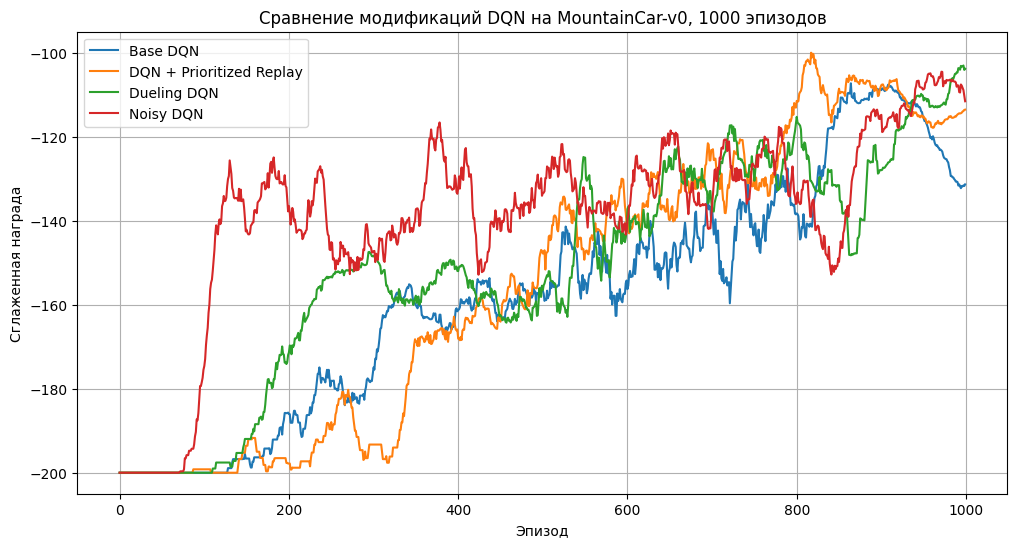

In [4]:
env_name = "MountainCar-v0"

plt.figure(figsize=(12, 6))

print(f"\n=== Запуск эксперимента на {env_name} ===")
for name, config in experiments.items():
    print(f"\nОбучение модели: {name}")
    rewards = train_agent(env_name, config, episodes=episodes)
    smoothed_rewards = smooth_curve(rewards)
    plt.plot(smoothed_rewards, label=name)

plt.title(f"Сравнение модификаций DQN на {env_name}, {episodes} эпизодов")
plt.xlabel("Эпизод")
plt.ylabel("Сглаженная награда")
plt.legend()
plt.grid()
plt.show()